In [1]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.nn.utils.rnn import pad_sequence

In [2]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
# Load and prepare data
data = pd.read_csv("ner_dataset.csv", encoding="latin1").ffill()
words = list(data["Word"].unique())
tags = list(data["Tag"].unique())

if "ENDPAD" not in words:
    words.append("ENDPAD")

word2idx = {w: i + 1 for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}
idx2tag = {i: t for t, i in tag2idx.items()}

In [6]:

data.head(50)

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O
5,Sentence: 1,through,IN,O
6,Sentence: 1,London,NNP,B-geo
7,Sentence: 1,to,TO,O
8,Sentence: 1,protest,VB,O
9,Sentence: 1,the,DT,O


In [7]:
print("Unique words in corpus:", data['Word'].nunique())
print("Unique tags in corpus:", data['Tag'].nunique())

Unique words in corpus: 35177
Unique tags in corpus: 17


In [8]:

print("Unique tags are:", tags)

Unique tags are: ['O', 'B-geo', 'B-gpe', 'B-per', 'I-geo', 'B-org', 'I-org', 'B-tim', 'B-art', 'I-art', 'I-per', 'I-gpe', 'I-tim', 'B-nat', 'B-eve', 'I-eve', 'I-nat']


In [9]:

# Group words by sentences
class SentenceGetter:
    def __init__(self, data):
        self.grouped = data.groupby("Sentence #", group_keys=False).apply(
            lambda s: [(w, t) for w, t in zip(s["Word"], s["Tag"])]
        )
        self.sentences = list(self.grouped)

getter = SentenceGetter(data)
sentences = getter.sentences

/tmp/ipython-input-228/1667867283.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.grouped = data.groupby("Sentence #", group_keys=False).apply(


In [10]:

sentences[35]

[('The', 'O'),
 ('U.S.', 'B-org'),
 ('Geological', 'I-org'),
 ('Survey', 'I-org'),
 ('gave', 'O'),
 ('a', 'O'),
 ('preliminary', 'O'),
 ('estimate', 'O'),
 ('of', 'O'),
 ('the', 'O'),
 ('strength', 'O'),
 ('of', 'O'),
 ('the', 'O'),
 ('Tuesday', 'B-tim'),
 ('morning', 'I-tim'),
 ('quake', 'O'),
 ('at', 'O'),
 ('6.7', 'O'),
 ('on', 'O'),
 ('the', 'O'),
 ('Richter', 'B-geo'),
 ('scale', 'O'),
 (',', 'O'),
 ('and', 'O'),
 ('said', 'O'),
 ('the', 'O'),
 ('epicenter', 'O'),
 ('was', 'O'),
 ('close', 'O'),
 ('to', 'O'),
 ('the', 'O'),
 ('island', 'O'),
 ('of', 'O'),
 ('Nias', 'B-org'),
 ('.', 'O')]

In [11]:
# Encode sentences
X = [[word2idx[w] for w, t in s] for s in sentences]
y = [[tag2idx[t] for w, t in s] for s in sentences]

In [12]:
y = [[tag2idx[t] for w, t in s] for s in sentences]


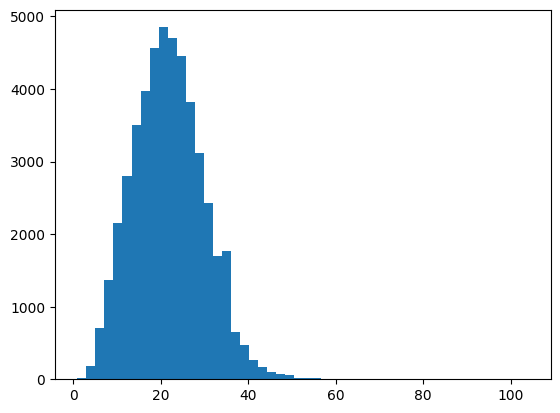

In [13]:
plt.hist([len(s) for s in sentences], bins=50)
plt.show()

In [16]:
# Pad sequences
max_len = 50
X_pad = pad_sequence([torch.tensor(seq) for seq in X], batch_first=True, padding_value=word2idx["ENDPAD"])
y_pad = pad_sequence([torch.tensor(seq) for seq in y], batch_first=True, padding_value=tag2idx["O"])
X_pad = X_pad[:, :max_len]
y_pad = y_pad[:, :max_len]


In [15]:

X_pad[0]

tensor([    1,     2,     3,     4,     5,     6,     7,     8,     9,    10,
           11,    12,    13,    14,    15,    10,    16,     2,    17,    18,
           19,    20,    21,    22, 35178, 35178, 35178, 35178, 35178, 35178,
        35178, 35178, 35178, 35178, 35178, 35178, 35178, 35178, 35178, 35178,
        35178, 35178, 35178, 35178, 35178, 35178, 35178, 35178, 35178, 35178])

In [17]:
y_pad[0]

tensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0])

In [18]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_pad, y_pad, test_size=0.2, random_state=1)

In [19]:
# Dataset class
class NERDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "input_ids": self.X[idx],
            "labels": self.y[idx]
        }

train_loader = DataLoader(NERDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(NERDataset(X_test, y_test), batch_size=32)


In [20]:
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, tagset_size, embedding_dim=128, hidden_dim=256):
        super(BiLSTMTagger, self).__init__()

        self.embedding = nn.Embedding(vocab_size + 1, embedding_dim, padding_idx=word2idx["ENDPAD"])
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim // 2,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, tagset_size)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        x, _ = self.lstm(x)
        logits = self.fc(x)
        return logits

In [21]:
model = BiLSTMTagger(len(word2idx), len(tag2idx)).to(device)

loss_fn = nn.CrossEntropyLoss(ignore_index=tag2idx["O"])

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [22]:
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=3):

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids)

            loss = loss_fn(
                outputs.view(-1, outputs.shape[-1]),
                labels.view(-1)
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch["input_ids"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(input_ids)

                loss = loss_fn(
                    outputs.view(-1, outputs.shape[-1]),
                    labels.view(-1)
                )

                val_loss += loss.item()

        avg_val_loss = val_loss / len(test_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    return train_losses, val_losses

In [23]:
def evaluate_model(model, test_loader, X_test, y_test):
    model.eval()
    true_tags, pred_tags = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=-1)
            for i in range(len(labels)):
                for j in range(len(labels[i])):
                    if labels[i][j] != tag2idx["O"]:
                        true_tags.append(idx2tag[labels[i][j].item()])
                        pred_tags.append(idx2tag[preds[i][j].item()])


In [25]:
# Run training and evaluation
train_losses, val_losses = train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=3)
evaluate_model(model, test_loader, X_test, y_test)


Epoch 1/3 | Train Loss: 0.4236 | Val Loss: 0.4692
Epoch 2/3 | Train Loss: 0.3005 | Val Loss: 0.4541
Epoch 3/3 | Train Loss: 0.2122 | Val Loss: 0.4780


Name: Somalaraju Rohini
Register Number: 212224240156 


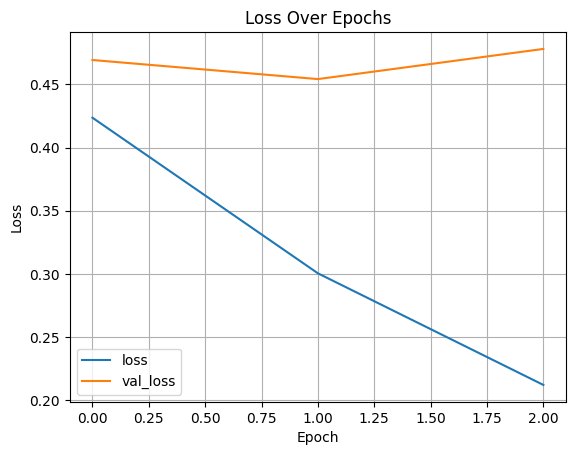

In [26]:
# Plot loss
print('Name: Somalaraju Rohini')
print('Register Number: 212224240156 ')
history_df = pd.DataFrame({"loss": train_losses, "val_loss": val_losses})
history_df.plot(title="Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [28]:
# ==============================
# Inference and prediction
# ==============================

# Find a sentence that actually contains named entities
for idx in range(len(y_test)):
    if any(tag.item() != tag2idx["O"] for tag in y_test[idx]):
        i = idx
        break

model.eval()
sample = X_test[i].unsqueeze(0).to(device)
output = model(sample)
preds = torch.argmax(output, dim=-1).squeeze().cpu().numpy()
true = y_test[i].numpy()

print('Name: Somalaraju Rohini')
print('Register Number: 212224240156')

print(f"\nSentence Index: {i}\n")

print("{:<15} {:<10} {:<10} {}".format("Word", "True", "Pred", "Match"))
print("-"*55)

correct = 0
total = 0
sentence_words = []

for w_id, true_tag, pred_tag in zip(X_test[i], y_test[i], preds):
    if w_id.item() != word2idx["ENDPAD"]:
        word = words[w_id.item() - 1]
        true_label = tags[true_tag.item()]
        pred_label = tags[pred_tag]

        match = "✓" if true_label == pred_label else "✗"

        print(f"{word:<15} {true_label:<10} {pred_label:<10} {match}")

        sentence_words.append(word)

        total += 1
        if true_label == pred_label:
            correct += 1

# Print full sentence
print("\nSentence:")
print(" ".join(sentence_words))

# Sentence accuracy
accuracy = correct / total if total > 0 else 0
print(f"\nSentence Accuracy: {accuracy:.2%}")

Name: Somalaraju Rohini
Register Number: 212224240156

Sentence Index: 1

Word            True       Pred       Match
-------------------------------------------------------
The             O          B-org      ✗
prisoners       O          B-per      ✗
'               O          B-gpe      ✗
identities      O          B-org      ✗
were            O          I-org      ✗
not             O          I-org      ✗
immediately     O          B-per      ✗
known           O          I-tim      ✗
,               O          I-tim      ✗
but             O          B-org      ✗
Israel          B-gpe      B-geo      ✗
has             O          B-org      ✗
said            O          B-per      ✗
it              O          B-per      ✗
would           O          B-per      ✗
not             O          I-per      ✗
release         O          B-per      ✗
those           O          B-per      ✗
it              O          I-per      ✗
said            O          I-per      ✗
had             O         